# HOUSE PRICE PREDICTION

## Problem Statement
It is our job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable.

## Importing Libararies

In [900]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

In [901]:
df= pd.read_csv("train.csv")

In [902]:
test_df=pd.read_csv("test.csv")

In [903]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [904]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## EDA

In [905]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [906]:
test_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

<Axes: xlabel='Id', ylabel='SalePrice'>

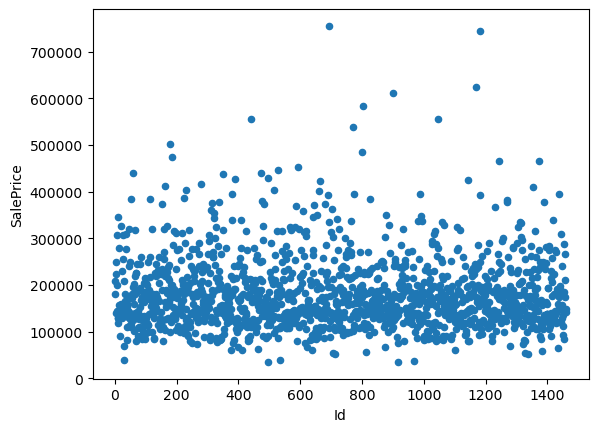

In [907]:
df.plot.scatter(x='Id', y ='SalePrice')

In [908]:
df.corr(numeric_only=True).SalePrice.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [909]:
df.isnull().mean().sort_values(ascending=False).head(10)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
dtype: float64

In [910]:
test_df.MSZoning.unique()

array(['RH', 'RL', 'RM', 'FV', 'C (all)', nan], dtype=object)

In [911]:
test_df.SaleType.unique()

array(['WD', 'COD', 'New', 'ConLD', 'Oth', 'Con', 'ConLw', 'ConLI', 'CWD',
       nan], dtype=object)

## Feature Engineering

In [912]:
df['SalePrice'] = np.log1p(df['SalePrice'])
test_df['SalePrice'] = np.log1p(df['SalePrice'])

In [913]:
df['TotalBath']= (df.FullBath + 0.5* df.HalfBath + df.BsmtFullBath + 0.5*df.BsmtHalfBath) 
test_df['TotalBath']= (test_df.FullBath + 0.5* test_df.HalfBath + test_df.BsmtFullBath) 

In [914]:
df['TotalPorchSF']= (df.OpenPorchSF + df.ScreenPorch + df.WoodDeckSF)
test_df['TotalPorchSF']= (test_df.OpenPorchSF + test_df.ScreenPorch + test_df.WoodDeckSF)

In [915]:
df['TotalSF']= (df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'])
test_df['TotalSF']= (test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF'])

In [916]:
df['HouseAge'] = (df['YearBuilt'] - df['YearRemodAdd'])
test_df['HouseAge'] = (test_df['YearBuilt'] - test_df['YearRemodAdd'])

In [917]:
df['TotalRooms'] = (df['TotRmsAbvGrd']/df['BedroomAbvGr'])
test_df['TotalRooms'] = (test_df['TotRmsAbvGrd']/test_df['BedroomAbvGr'])

In [918]:
df['TotalArea'] = (df['TotalBsmtSF'] +df['1stFlrSF'] +df['2ndFlrSF'] +df['GarageArea'])
test_df['TotalArea'] = (test_df['TotalBsmtSF'] +test_df['1stFlrSF'] +test_df['2ndFlrSF'] +test_df['GarageArea'])


## Data Cleaning

In [919]:
df=df.drop(columns=['BsmtFinSF2','MiscVal','LowQualFinSF','YrSold' ,
                    'OverallCond','MSSubClass','EnclosedPorch','KitchenAbvGr','PoolQC', 
                    'MiscFeature', 'Alley', 'Fence','3SsnPorch','Id','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath' ])
test_df=test_df.drop(columns=['BsmtFinSF2','MiscVal','LowQualFinSF','YrSold' ,
                    'OverallCond','MSSubClass','EnclosedPorch','KitchenAbvGr','PoolQC', 
                    'MiscFeature', 'Alley', 'Fence','3SsnPorch','Id','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath' ])

In [920]:
df['LotFrontage']= df['LotFrontage'].fillna(df['LotFrontage'].median())
test_df['LotFrontage']= test_df['LotFrontage'].fillna(test_df['LotFrontage'].median())

In [921]:
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])
test_df['MSZoning'] = test_df['MSZoning'].fillna(test_df['MSZoning'].mode()[0])

In [922]:
df['SaleType'] = df['SaleType'].fillna(df['SaleType'].mode()[0])
test_df['SaleType'] = test_df['SaleType'].fillna(test_df['SaleType'].mode()[0])

In [923]:
df= pd.get_dummies(df, drop_first=True)
test_df = pd.get_dummies(test_df, drop_first=True)

In [924]:
df=df.fillna(0)
test_df=test_df.fillna(0)

## Training Model

In [925]:
df = df.replace([np.inf, -np.inf],0)
test_df = test_df.replace([np.inf, -np.inf],0)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
y = np.log1p(y)

In [926]:
from sklearn.model_selection import train_test_split
tts = train_test_split
X_train , X_test , y_train , y_test = tts(X, y,test_size=0.2, random_state=42 )

In [927]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
scores = cross_val_score(pipeline, X, y, scoring='neg_mean_squared_error', cv=10)
rmse = np.sqrt(-scores.mean())
print(rmse)

0.014316174153366086


In [928]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [929]:
clf.fit(X_train,y_train)

LinearRegression()

## Model Evaluation

In [930]:
from sklearn.model_selection import cross_val_predict

In [931]:
reg_pred = clf.predict(X_test)
print(reg_pred)

[2.55615224 2.62061625 2.52401615 2.5643122  2.61343872 2.50800351
 2.59253499 2.55878604 2.50318401 2.54783027 2.5557543  2.53940425
 2.50581216 2.58519751 2.56908325 2.54725754 2.57766506 2.5470285
 2.53472476 2.58597494 2.56533989 2.58377883 2.5693471  2.54974651
 2.58011829 2.55718218 2.57796041 2.53571985 2.57307085 2.57860623
 2.57242668 2.60513742 2.58391635 2.53664465 2.59896891 2.5588451
 2.56039448 2.58017945 2.61181734 2.53289127 2.55011337 2.58839693
 2.53683373 2.6258972  2.54689344 2.55718784 2.53152805 2.54621035
 2.64439868 2.55756875 2.53853625 2.5851695  2.52843622 2.61172085
 2.56528982 2.59425453 2.5817141  2.56026156 2.55047095 2.52060023
 2.50785854 2.5616052  2.61281373 2.59725978 2.60880847 2.57864018
 2.535368   2.61478267 2.54365192 2.56688836 2.54408649 2.54588723
 2.53633369 2.51128262 2.64644333 2.57812895 2.6124599  2.61453117
 2.55856219 2.54193292 2.53416216 2.51548517 2.53628045 2.52849496
 2.55924901 2.54940741 2.60219165 2.57886159 2.55466303 2.576377

In [932]:
from sklearn.metrics import r2_score

In [933]:
score =r2_score(y_test,reg_pred)
print(score)

0.7679987984964999


## Conclusion

The Linear Regression model achieved 76% accuracy in predicting house prices, demonstrating that structured feature engineering and proper data preprocessing can yield meaningful results with even a simple baseline model.

## Submission

In [934]:
missing = set(df.columns) - set(test_df.columns)
extra   = set(test_df.columns) - set(df.columns)

print(f"Missing from test_df ({len(missing)}): {missing}")
print(f"Extra in test_df ({len(extra)}): {extra}")

Missing from test_df (16): {'Exterior1st_Stone', 'Condition2_RRAn', 'Condition2_RRAe', 'Exterior1st_ImStucc', 'RoofMatl_Metal', 'Electrical_Mix', 'HouseStyle_2.5Fin', 'Heating_OthW', 'Condition2_RRNn', 'RoofMatl_CompShg', 'Utilities_NoSeWa', 'Heating_GasA', 'RoofMatl_Roll', 'GarageQual_Fa', 'RoofMatl_Membran', 'Exterior2nd_Other'}
Extra in test_df (0): set()


In [935]:
test_df_aligned = test_df.reindex(columns=X.columns, fill_value=0)
clf.predict(test_df_aligned.values)

array([46.62582595, 56.45017555, 57.31542326, ..., 66.5763779 ,
       44.30528594, 54.08559002])

In [939]:
test_data=pd.read_csv('test.csv')
test_id = test_data['Id']
Predictions = clf.predict(test_df_aligned.values)
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': Predictions
})

submission.to_csv('submission.csv', index=False)